# Lab - Texture Analysis

## Part A

### Objective

The goal of this part is to segment the following photo into 3 segments:
1. a segment for clothes with a jeans texture
2. a segment for clothes with a cotton texture
3. a segment for the background

<img src='test.jpg' width=100px heigth=300px></img>

In [1]:
# All the imports you will need in the whole lab
from skimage.feature import graycomatrix, graycoprops
from skimage import io
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
import os
import numpy as np

## Section 1

In this section, you will extract features from image samples of the jeans and cotton texture using GLCM, then we will plot our feature space to see if our features are able to differentiate between the textures of jeans, cotton, and background.

### TODO Implement get_glcm_features

You will need the following two functions:

greycomatrix, doc link -> https://scikit-image.org/docs/dev/api/skimage.feature.html#greycomatrix <br>
greycoprops, doc link -> https://scikit-image.org/docs/dev/api/skimage.feature.html#skimage.feature.greycoprops

In [2]:
def get_glcm_features(gray_scale_img):
    """
    Given a grayscale image with graylevels from 0 - 255, this function returns the contrast
    and the homogeneity features of the image with the help of GLCM
    """
    # Tip: Make sure you understand the input-output of everything you write,
    # not doing that results in bugs that make you believe the lab is long
    
    # graycomatrix: Creates a Gray Level Co-occurrence Matrix (GLCM)
    # Inputs:
    #   - gray_scale_img: 2D array of grayscale image (0-255)
    #   - distances: list of pixel pair distances (we use [1] for adjacent pixels)
    #   - angles: list of angles in radians (we use [0] for horizontal direction)
    #   - levels: number of gray levels (256 for 8-bit images)
    #   - symmetric: if True, matrix is symmetric (counts both directions)
    #   - normed: if True, normalizes the matrix
    # Output: 4D array of shape (levels, levels, len(distances), len(angles))
    #         representing the co-occurrence matrix
    glcm = graycomatrix(gray_scale_img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    
    # graycoprops: Extracts texture properties from GLCM
    # Inputs:
    #   - glcm: the GLCM matrix from graycomatrix
    #   - prop: property to calculate ('contrast', 'homogeneity', 'energy', 'correlation', etc.)
    # Output: 2D array of shape (len(distances), len(angles)) containing the property values
    #         We use [0, 0] to get the single value for our single distance and angle
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

    return contrast, homogeneity

The following part will extract the contrast and homogeneity of samples of jeans and cotton in the folder "imgs_patches" using your function. So, for each sample image, we will have a point in a 2D feature space. Then, it will plot this feature space.

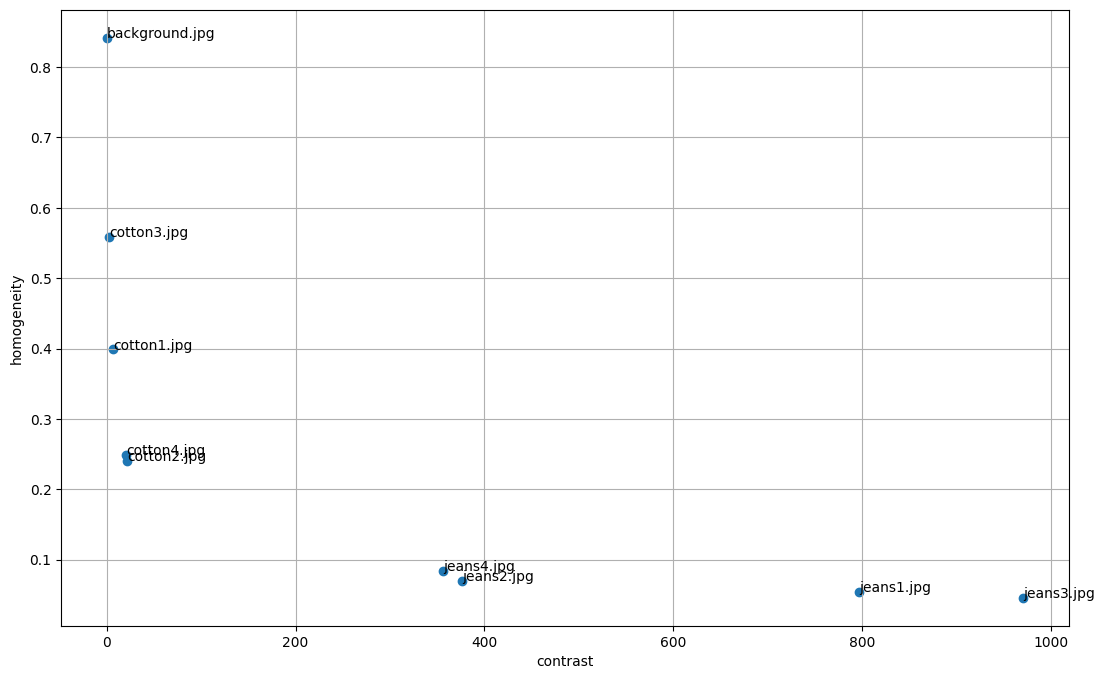

In [3]:
# You don't need to understand how this function works
def get_fname_images_tuple(directory):
    fnames = os.listdir(directory)
    to_return = []
    for fn in fnames:
        if fn[-3:] == 'jpg':
            path = os.path.join(directory, fn)
            gray_scale_image = (rgb2gray(io.imread(path)) * 255).astype(np.uint8)
            to_return.append((fn, gray_scale_image))
        else:
            print('This file has been skipped', fn)
    return to_return

# You don't need to understand how this function works
def plot_2d_features_with_names(names_fts_list, xlabel, ylabel):
    x = [names_fts[1][0] for names_fts in names_fts_list]
    y = [names_fts[1][1] for names_fts in names_fts_list]
    txts = [names_fts[0] for names_fts in names_fts_list]

    fig, ax = plt.subplots()
    ax.scatter(x, y)

    for i, txt in enumerate(txts):
        ax.annotate(txt, (x[i], y[i]))
    ax.grid()
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    fig = plt.gcf()
    fig.set_size_inches(13, 8)


fn_img_list = get_fname_images_tuple(r'imgs_patches')

fn_ft_list = []
for fn, img in fn_img_list:
    fn_ft_list.append((fn, get_glcm_features(img)))

plot_2d_features_with_names(fn_ft_list, 'contrast', 'homogeneity')

## Section 2

You should have noticed that the previous section showed us that we can differentiate between jeans, cotton, & background patches using contrast and homogeneity. So, in this section, we will classify an unknown patch into one of those categories using a simple rule-based classifier. This will make us able to segment an image.

In [4]:
# TODO implement this function

def classify_patch(contrast, homogeneity):
    """
    Given the contrast and homogeneity values of a certain image patch, this function
    will return the class of the patch, i.e either 'jeans', 'cotton', or 'background'
    """
    # Hint: We can decide whether the patch is background or not by simply checking 'if' the homogeneity is greater than a certain float value
    
    # Background has high homogeneity (uniform texture)
    if homogeneity > 0.9:
        return 'background'
    # Jeans has higher contrast than cotton
    elif contrast > 150:
        return 'jeans'
    else:
        return 'cotton'

### TODO Complete todos in segment_img

This function is given an RGB image, and returns the segmented image coloring jeans patches in green, cotton patches in red, and the background in blue. Your final output should look like the following image:

<img src='target_output.jpg' width=100px heigth=300px></img>

In [5]:
def segment_img(image):
    img = image.copy()
    patch_height = patch_width = 50

    # TODO complete the following skeleton

    # loop on the image patch by patch
    for i in range(0, img.shape[0], patch_height):
        for j in range(0, img.shape[1], patch_width):
            # Get the corresponding image patch
            patch = img[i:i+patch_height, j:j+patch_width]
            
            # Skip if patch is too small
            if patch.shape[0] < patch_height or patch.shape[1] < patch_width:
                continue

            patch_grayscale = (rgb2gray(patch) * 255).astype(np.uint8)

            contrast, homogeneity = get_glcm_features(patch_grayscale)
            classification = classify_patch(contrast, homogeneity)

            if classification == 'cotton':
                patch[:,:, 0] = 255
            elif classification == 'jeans':
                patch[:,:, 1] = 255
            else:
                patch[:,:,2] = 255

    return img

/tmp/ipykernel_286479/603554719.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(segmented_image)


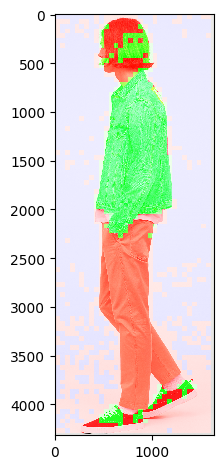

In [6]:
# Testing your work
image = io.imread('test.jpg')
segmented_image = segment_img(image)
io.imshow(segmented_image)

## Part B

You are required to implement your own function that computes the LBP histogram of a grayscale image (return to lecture slides for reference attached in this lab folder).

#### Note: you are allowed to ignore image border pixels.

In [7]:
def get_lbp_hist(grayscale_img):
    """
    Computes the Local Binary Pattern (LBP) histogram of a grayscale image.
    LBP compares each pixel with its 8 neighbors to create a binary pattern.
    
    Note: Border pixels are ignored as they don't have all 8 neighbors.
    """
    # Get image dimensions
    rows, cols = grayscale_img.shape
    
    # Initialize histogram with 256 bins (2^8 possible patterns)
    lbp_histogram = np.zeros(256, dtype=int)
    
    # Loop through image pixels (excluding border)
    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            # Get center pixel value
            center = grayscale_img[i, j]
            
            # Compare 8 neighbors with center pixel (clockwise from top-left)
            # If neighbor >= center, set bit to 1, else 0
            binary_pattern = 0
            
            # Top-left neighbor
            binary_pattern |= (1 << 7) if grayscale_img[i-1, j-1] >= center else 0
            # Top neighbor
            binary_pattern |= (1 << 6) if grayscale_img[i-1, j] >= center else 0
            # Top-right neighbor
            binary_pattern |= (1 << 5) if grayscale_img[i-1, j+1] >= center else 0
            # Right neighbor
            binary_pattern |= (1 << 4) if grayscale_img[i, j+1] >= center else 0
            # Bottom-right neighbor
            binary_pattern |= (1 << 3) if grayscale_img[i+1, j+1] >= center else 0
            # Bottom neighbor
            binary_pattern |= (1 << 2) if grayscale_img[i+1, j] >= center else 0
            # Bottom-left neighbor
            binary_pattern |= (1 << 1) if grayscale_img[i+1, j-1] >= center else 0
            # Left neighbor
            binary_pattern |= (1 << 0) if grayscale_img[i, j-1] >= center else 0
            
            # Increment the corresponding bin in histogram
            lbp_histogram[binary_pattern] += 1
    
    return lbp_histogram

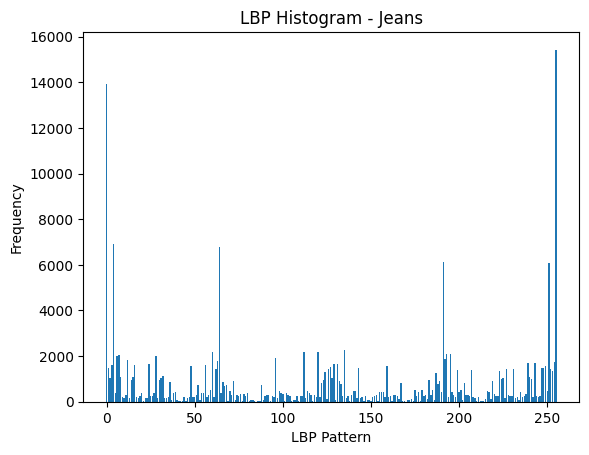

In [11]:
# Testing your work, we will compare your histogram with that of ours
# There should be a noticable difference between the histograms of jeans and cotton
img = rgb2gray(io.imread(r'imgs_patches/jeans1.jpg'))
hist = get_lbp_hist(img)
plt.bar(range(256), hist)
plt.xlabel('LBP Pattern')
plt.ylabel('Frequency')
plt.title('LBP Histogram - Jeans')
plt.show()

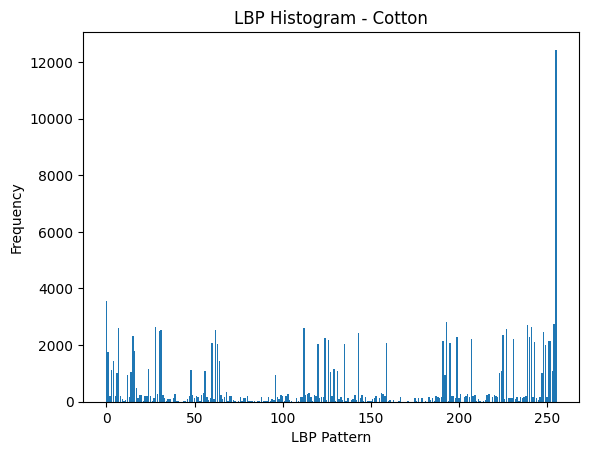

In [10]:
# Testing your work, we will compare your histogram with that of ours
# There should be a noticable difference between the histograms of jeans and cotton
img = rgb2gray(io.imread(r'imgs_patches/cotton1.jpg'))
hist = get_lbp_hist(img)
plt.bar(range(256), hist)
plt.xlabel('LBP Pattern')
plt.ylabel('Frequency')
plt.title('LBP Histogram - Cotton')
plt.show()